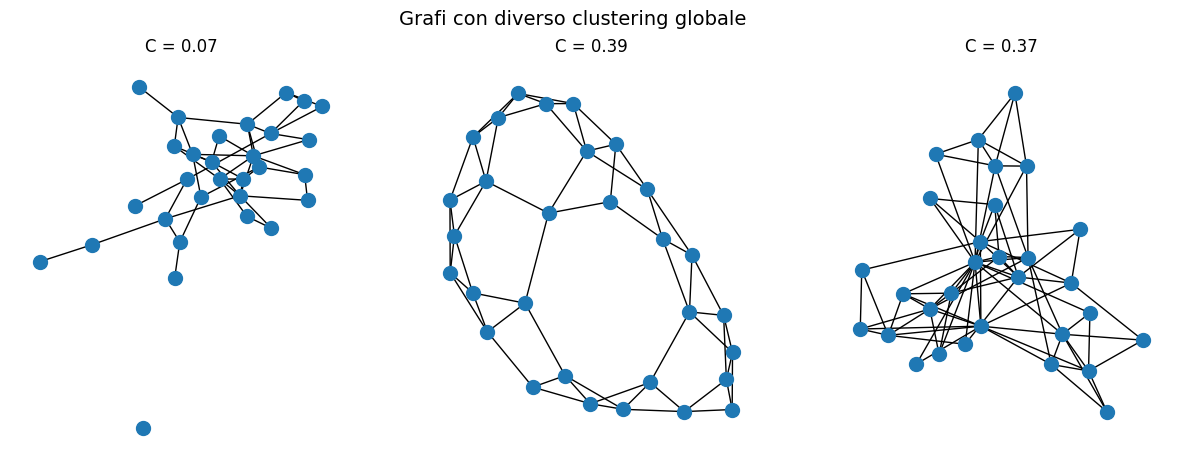

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Numero nodi
N = 30

# 1. Grafo casuale (clustering basso)
G1 = nx.erdos_renyi_graph(N, 0.1)

# 2. Small-world (clustering medio-alto)
G2 = nx.watts_strogatz_graph(N, k=4, p=0.1)

# 3. Grafo con clustering alto (triadi/cluster)
G3 = nx.powerlaw_cluster_graph(N, m=3, p=0.8)

graphs = [G1, G2, G3]
titles = []

# Calcolo clustering globale (transitivity)
for G in graphs:
    C = nx.transitivity(G)
    titles.append(f"C = {C:.2f}")

# Plot
plt.figure(figsize=(15, 5))

for i, G in enumerate(graphs):
    plt.subplot(1, 3, i+1)
    
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=False, node_size=100)
    
    plt.title(titles[i])

plt.suptitle("Grafi con diverso clustering globale", fontsize=14)
plt.show()

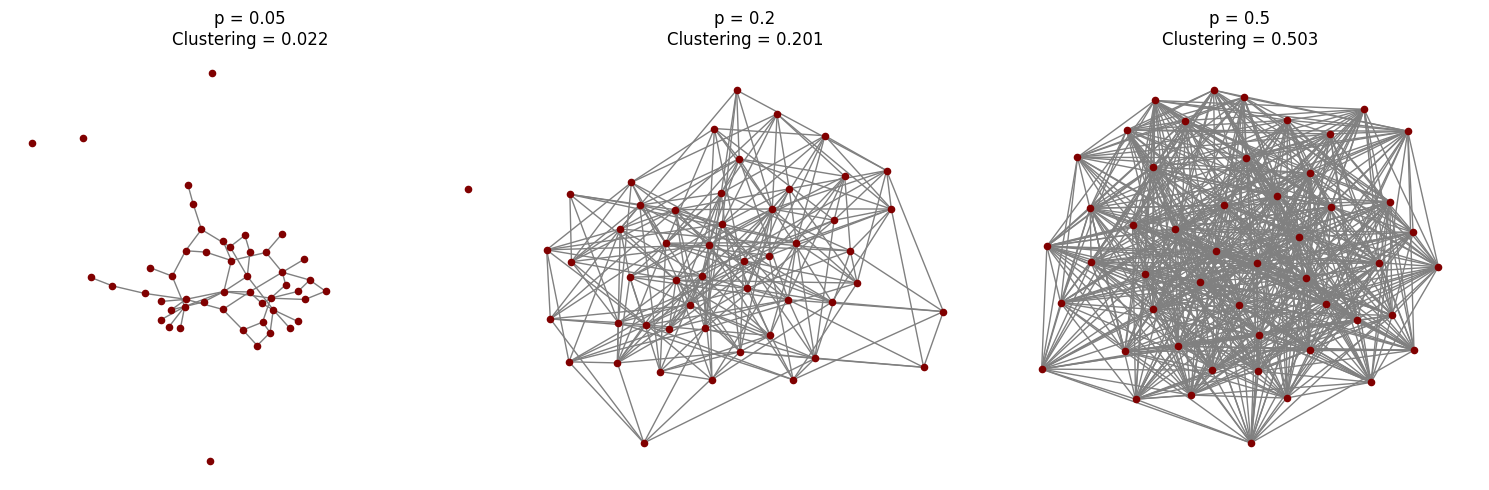

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Parameters
N = 50
p_values = [0.05, 0.2, 0.5]   # valori di p → clustering diverso

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, p in zip(axes, p_values):
    # Generate graph
    G = nx.gnp_random_graph(N, p)
    
    # Compute global clustering
    C = nx.average_clustering(G)
    
    # Layout (fixed seed for reproducibility)
    pos = nx.spring_layout(G, seed=42)
    
    # Draw graph
    nx.draw(G, pos, node_size=20, node_color="#800000", edge_color="gray", ax=ax)
    
    # Title with clustering value
    ax.set_title(f"p = {p}\nClustering = {C:.3f}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


Clustering globale: 0.20542382798132788


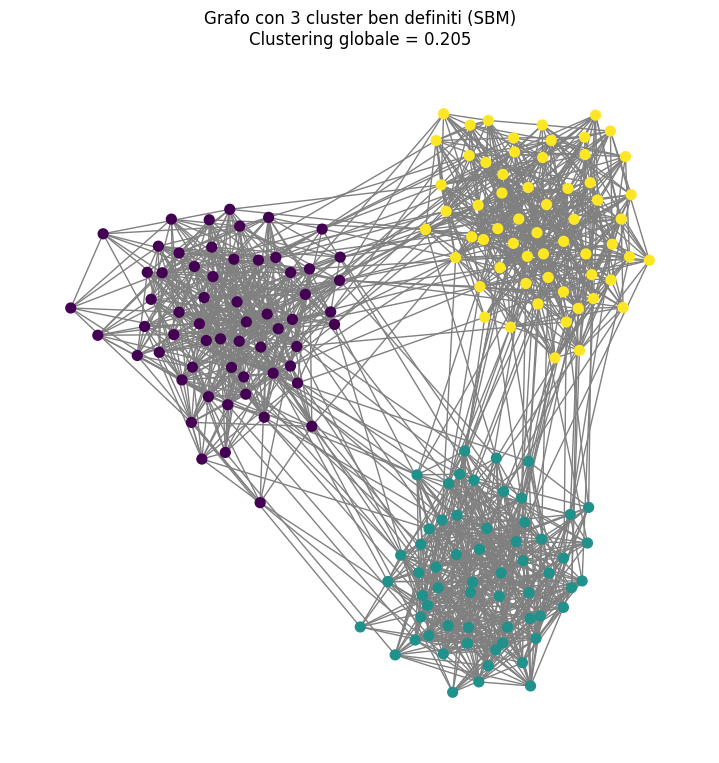

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# Numero di nodi per cluster
sizes = [60, 60, 60]   # 3 cluster da 60 nodi ciascuno

# Probabilità di connessione
p_in = 0.25   # alta probabilità dentro il cluster
p_out = 0.01  # bassa probabilità tra cluster

# Matrice delle probabilità (SBM)
probs = [
    [p_in,  p_out, p_out],
    [p_out, p_in,  p_out],
    [p_out, p_out, p_in]
]

# Genera grafo SBM
G = nx.stochastic_block_model(sizes, probs, seed=42)

# Calcolo del clustering globale
global_clustering = nx.average_clustering(G)
print("Clustering globale:", global_clustering)

# Layout che evidenzia i cluster
pos = nx.spring_layout(G, seed=42)

# Colori diversi per cluster
colors = []
for i, size in enumerate(sizes):
    colors += [i] * size

plt.figure(figsize=(7, 7))
nx.draw(G, pos, node_color=colors, cmap="viridis", node_size=50, edge_color="gray")
plt.title(f"Grafo con 3 cluster ben definiti (SBM)\nClustering globale = {global_clustering:.3f}")
plt.axis("off")
plt.show()


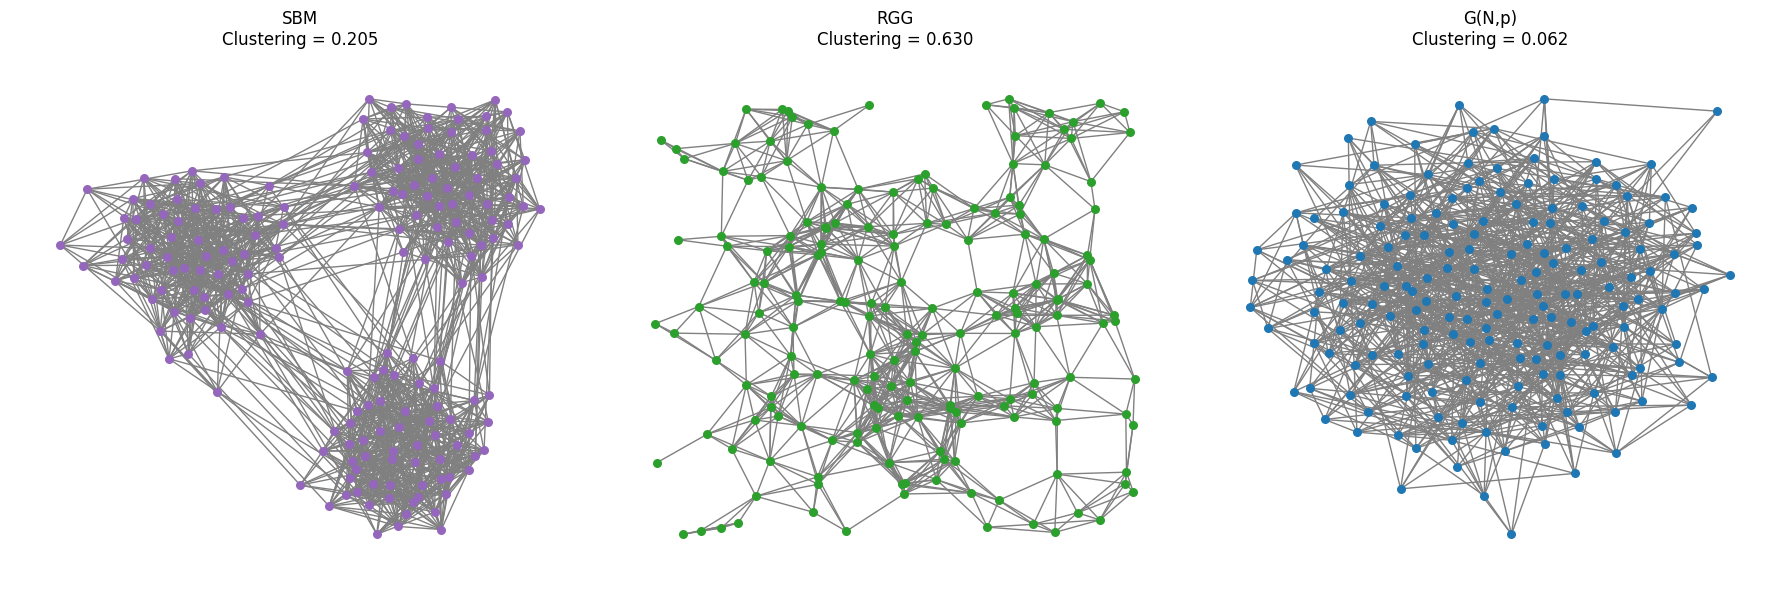

Clustering SBM: 0.20542382798132788
Clustering RGG: 0.6302321333421302
Clustering ER : 0.06235236612945592


In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import pdist, squareform

N = 180   # numero totale di nodi

# -----------------------------
# 1) SBM con 3 cluster
# -----------------------------
sizes = [60, 60, 60]
p_in = 0.25
p_out = 0.01

probs = [
    [p_in, p_out, p_out],
    [p_out, p_in, p_out],
    [p_out, p_out, p_in]
]

G_sbm = nx.stochastic_block_model(sizes, probs, seed=42)
C_sbm = nx.average_clustering(G_sbm)

# -----------------------------
# 2) RGG con stesso N
# -----------------------------
def generate_rgg(N, r):
    points = np.random.rand(N, 2)
    dist_matrix = squareform(pdist(points))
    G = nx.Graph()
    for i in range(N):
        G.add_node(i, pos=points[i])
    for i in range(N):
        for j in range(i+1, N):
            if dist_matrix[i, j] <= r:
                G.add_edge(i, j)
    return G

r = 0.15
G_rgg = generate_rgg(N, r)
C_rgg = nx.average_clustering(G_rgg)

# -----------------------------
# 3) G(N,p) con stesso grado medio dell’RGG
# -----------------------------
avg_deg_rgg = sum(dict(G_rgg.degree()).values()) / N
p = avg_deg_rgg / (N - 1)

G_er = nx.gnp_random_graph(N, p, seed=42)
C_er = nx.average_clustering(G_er)

# -----------------------------
# Plot dei tre grafi
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# SBM
pos_sbm = nx.spring_layout(G_sbm, seed=42)
nx.draw(G_sbm, pos_sbm, node_size=30, node_color="tab:purple", edge_color="gray", ax=axes[0])
axes[0].set_title(f"SBM\nClustering = {C_sbm:.3f}")
axes[0].axis("off")

# RGG
pos_rgg = {i: G_rgg.nodes[i]["pos"] for i in G_rgg.nodes()}
nx.draw(G_rgg, pos_rgg, node_size=30, node_color="tab:green", edge_color="gray", ax=axes[1])
axes[1].set_title(f"RGG\nClustering = {C_rgg:.3f}")
axes[1].axis("off")

# ER
pos_er = nx.spring_layout(G_er, seed=42)
nx.draw(G_er, pos_er, node_size=30, node_color="tab:blue", edge_color="gray", ax=axes[2])
axes[2].set_title(f"G(N,p)\nClustering = {C_er:.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# Stampa dei valori numerici
# -----------------------------
print("Clustering SBM:", C_sbm)
print("Clustering RGG:", C_rgg)
print("Clustering ER :", C_er)
